In [57]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import random
import cv2
import matplotlib.pyplot as plt
import random

In [58]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [59]:
CLINICAL_PATH = "/Users/taliacho/Downloads/Ranger/Bryan-Ranger/clinical_data/ABS_all_bw"
PHANTOM_PATH  = "/Users/taliacho/Downloads/Ranger/Bryan-Ranger/local_data/abs_neonatal_bw" 

N_CLINICAL_TRAIN = 270   # how many clinical images for training
N_CLINICAL_TEST  = 68    # how many clinical images for testing

N_PHANTOM_TRAIN  = 270    # how many phantom images for training
N_PHANTOM_TEST   = 68    # how many phantom images for testing

RANDOM_SEED = 42
IMG_SIZE    = (128, 128)

In [60]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        conv_out = self.conv(x)
        pooled = self.pool(conv_out)
        return conv_out, pooled

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [61]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = Encoder(3, 64)
        self.enc2 = Encoder(64, 128)
        self.enc3 = Encoder(128, 256)
        self.enc4 = Encoder(256, 512)

        self.bottleneck = ConvBlock(512, 1024)

        self.dec1 = Decoder(1024, 512)
        self.dec2 = Decoder(512, 256)
        self.dec3 = Decoder(256, 128)
        self.dec4 = Decoder(128, 64)

        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d1 = self.dec1(b, s4)
        d2 = self.dec2(d1, s3)
        d3 = self.dec3(d2, s2)
        d4 = self.dec4(d3, s1)

        out = self.final_conv(d4)
        return self.sigmoid(out)

In [62]:
class SegmentationDataset(Dataset):
    def __init__(self, folder_path, file_list, img_size=(128, 128)):
        self.folder_path = folder_path
        self.img_size    = img_size
        self.image_files = file_list

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file  = self.image_files[idx]
        mask_file = img_file.replace(".jpeg", "_m.jpeg")

        image = Image.open(os.path.join(self.folder_path, img_file)).convert("RGB").resize(self.img_size)
        mask  = Image.open(os.path.join(self.folder_path, mask_file)).convert("L").resize(self.img_size)

        # Apply CLAHE to each RGB channel independently
        image_np = np.array(image)
        clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
        for c in range(3):
            image_np[:, :, c] = clahe.apply(image_np[:, :, c])

        image = torch.from_numpy(image_np / 255.0).permute(2, 0, 1).float()
        mask  = torch.from_numpy((np.array(mask) / 255.0 > 0.5).astype(np.float32)).unsqueeze(0)

        return image, mask

In [63]:
def sample_files(folder_path, n, seed=42):
    all_files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith(".jpeg") and not f.endswith("_m.jpeg")
    ])
    if n > len(all_files):
        raise ValueError(f"Requested {n} files but only {len(all_files)} available in {folder_path}")
    random.seed(seed)
    return random.sample(all_files, n)

In [64]:
# Sample from each source (train + test counts must not exceed available files)
clinical_train_files = sample_files(CLINICAL_PATH, N_CLINICAL_TRAIN, seed=RANDOM_SEED)

# For test, exclude files already used in train to avoid leakage
all_clinical = sorted([f for f in os.listdir(CLINICAL_PATH) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])
clinical_remaining = [f for f in all_clinical if f not in clinical_train_files]
random.seed(RANDOM_SEED + 1)
clinical_test_files = random.sample(clinical_remaining, N_CLINICAL_TEST)

phantom_train_files = sample_files(PHANTOM_PATH, N_PHANTOM_TRAIN, seed=RANDOM_SEED)
all_phantom = sorted([f for f in os.listdir(PHANTOM_PATH) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])
phantom_remaining = [f for f in all_phantom if f not in phantom_train_files]
random.seed(RANDOM_SEED + 2)
phantom_test_files = random.sample(phantom_remaining, N_PHANTOM_TEST)

# Build datasets
train_dataset = ConcatDataset([
    SegmentationDataset(CLINICAL_PATH, clinical_train_files, IMG_SIZE),
    SegmentationDataset(PHANTOM_PATH,  phantom_train_files,  IMG_SIZE),
])

test_dataset = ConcatDataset([
    SegmentationDataset(CLINICAL_PATH, clinical_test_files, IMG_SIZE),
    SegmentationDataset(PHANTOM_PATH,  phantom_test_files,  IMG_SIZE),
])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

print(f"Train: {N_CLINICAL_TRAIN} clinical + {N_PHANTOM_TRAIN} phantom = {len(train_dataset)} total")
print(f"Test:  {N_CLINICAL_TEST} clinical + {N_PHANTOM_TEST} phantom = {len(test_dataset)} total")


Train: 270 clinical + 270 phantom = 540 total
Test:  68 clinical + 68 phantom = 136 total


In [65]:
def dice_coefficient(preds, targets, smooth=1e-6):
    preds   = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)


In [66]:
model     = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = total_dice = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss    = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_coefficient(outputs > 0.5, masks).item()

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {total_loss/len(train_loader):.4f}, "
          f"Dice: {total_dice/len(train_loader):.4f}")


# ── Evaluation ────────────────────────────────

model.eval()
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = (model(images) > 0.5).float()
        total_dice += dice_coefficient(preds, masks).item()

print(f"\nTest Dice Score: {total_dice / len(test_loader):.4f}")

Epoch 1/5, Loss: 0.3225, Dice: 0.7396
Epoch 2/5, Loss: 0.2063, Dice: 0.8235
Epoch 3/5, Loss: 0.1721, Dice: 0.8476
Epoch 4/5, Loss: 0.1605, Dice: 0.8518
Epoch 5/5, Loss: 0.1403, Dice: 0.8680

Test Dice Score: 0.6794


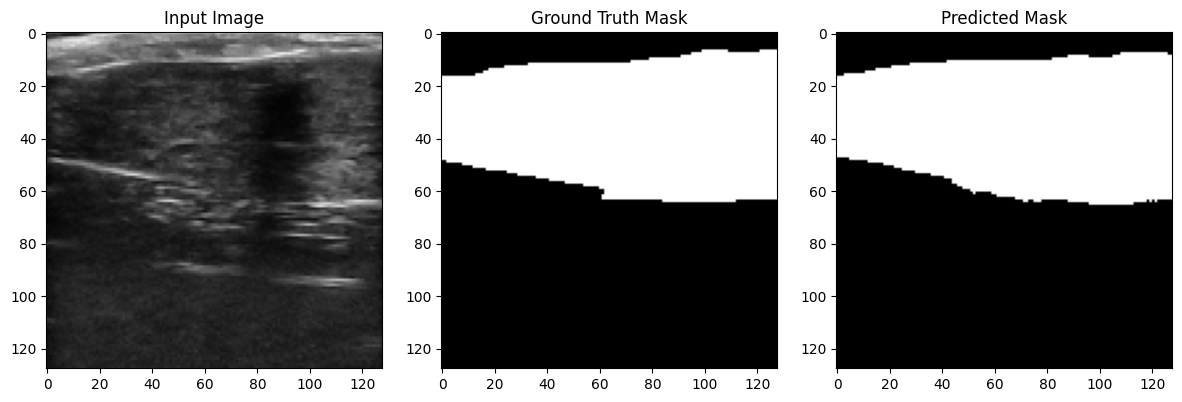

In [67]:
model.eval()
with torch.no_grad():
    rand_idx = random.randint(0, len(test_dataset) - 1)
    img, mask = test_dataset[rand_idx]
    img_input = img.unsqueeze(0).to(device)
    pred = model(img_input).cpu().numpy()[0, 0]
    pred_bin = (pred > 0.5).astype(np.uint8) * 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0).cpu())
plt.title("Input Image")
plt.subplot(1, 3, 2)
plt.imshow(mask[0].cpu(), cmap='gray')
plt.title("Ground Truth Mask")
plt.subplot(1, 3, 3)
plt.imshow(pred_bin, cmap='gray')
plt.title("Predicted Mask")
plt.tight_layout()
plt.show()

In [68]:
print(f"\n--- Dataset Summary ---")
print(f"Train: {N_CLINICAL_TRAIN} clinical + {N_PHANTOM_TRAIN} phantom = {len(train_dataset)} total")
print(f"Test:  {N_CLINICAL_TEST} clinical + {N_PHANTOM_TEST} phantom = {len(test_dataset)} total")


--- Dataset Summary ---
Train: 270 clinical + 270 phantom = 540 total
Test:  68 clinical + 68 phantom = 136 total
